# Model Training
Preliminary data cleaning has been implemented in the previous notebook. The purpose of this notebook is to prepare the data for machine learning. The previous datacleaning notebook maintained some variables that will not be used here, and are retained as such because of EDA. 


In [130]:
# --- Core data handling ---
import pandas as pd
import numpy as np

# --- Train/test split ---
from sklearn.model_selection import train_test_split

# --- Preprocessing ---
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Models ---
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV
from sklearn.dummy import DummyRegressor

# --- Evaluation metrics ---
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    confusion_matrix,
    classification_report
)

# --- Visualization (for confusion matrix / comparison charts) ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Export ---
import joblib
import os

# --- Reproducibility ---
RANDOM_STATE = 42

In [131]:
df = pd.read_csv("final_extract_dataset.csv")
df.head()

,Country_Code,Nation,Region_Code,Median_Malaria_Cases,Median_GDP,Median_Population_Density,Median_Urban_pct,Median_Sanitation_Access_pct,lat,lon,Median_Rainfall,Median_Temp
0,AFG,Afghanistan,EMR,176952.5,496.602504,58.041061,25.202968,48.212036,34.52,69.18,324.2,12.933425
1,DZA,Algeria,AFR,1089.0,4565.938916,18.177696,72.768284,86.051988,36.75,3.05,510.7,17.682192
2,AGO,Angola,AFR,7199337.0,2728.296658,25.969064,67.060305,49.416773,-8.83,13.22,484.0,25.430137
3,ARG,Argentina,AMR,14.5,13189.794406,16.433526,91.900344,94.620682,-34.58,-58.67,955.0,17.125683
4,ARM,Armenia,EUR,2.0,4432.954904,105.056940,65.089460,92.629303,40.17,44.50,363.6,13.506849


### 1. Feature Target Split

In [132]:
feature_cols = [
    'Region_Code',
    'Median_GDP',
    'Median_Population_Density',
    'Median_Urban_pct',
    'Median_Sanitation_Access_pct',
    'Median_Rainfall',
    'Median_Temp'
]

X = df[feature_cols]
y = np.log1p(df['Median_Malaria_Cases'])
y_raw = df['Median_Malaria_Cases']



print(X.shape, y.shape)
print(X.dtypes)



(99, 7) (99,)
Region_Code                      object
Median_GDP                      float64
Median_Population_Density       float64
Median_Urban_pct                float64
Median_Sanitation_Access_pct    float64
Median_Rainfall                 float64
Median_Temp                     float64
dtype: object


### 2. Train-Test Split

In [133]:
df['Region_Code'].value_counts()


Region_Code
AFR     43
AMR     20
WPR     11
EUR      9
EMR      8
SEAR     8
Name: count, dtype: int64

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=X['Region_Code']
      # we need to evenly distribute the region code in test and train data because 
      # some countries as shwon above have only a few region codes. 
)


print(X_train.shape, X_test.shape)
print(X_train['Region_Code'].value_counts())
print(X_test['Region_Code'].value_counts())

(79, 7) (20, 7)
Region_Code
AFR     34
AMR     16
WPR      9
EUR      7
SEAR     7
EMR      6
Name: count, dtype: int64
Region_Code
AFR     9
AMR     4
EUR     2
WPR     2
EMR     2
SEAR    1
Name: count, dtype: int64


### 3. Create Pipelines per model

In [135]:
#OHE the region code
categorical_cols = ['Region_Code']
numeric_cols = [
    'Median_GDP',
    'Median_Population_Density',
    'Median_Urban_pct',
    'Median_Sanitation_Access_pct',
    'Median_Rainfall',
    'Median_Temp'
]

preprocessor = ColumnTransformer(transformers=[
    #if Streamlit ever gets an input with a region code that's malformed or unexpected, it won't crash, it'll just zero out that encoding
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
    
    ('num', StandardScaler(), numeric_cols)
])


In [136]:

alphas_wide = np.logspace(-3, 6, 100)  # 0.001 to 1,000,000, more candidates too

models = {
     #MLR and Baseline_Median have no alpha to tune, so they're just plain estimators — no CV involved for them
    'MLR': LinearRegression(),
    'Ridge': RidgeCV(alphas=alphas_wide, cv=5),
    'Lasso': LassoCV(alphas=alphas_wide, cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'ElasticNet': ElasticNetCV(alphas=alphas_wide, cv=5, random_state=RANDOM_STATE, max_iter=10000),
    'Baseline_Median': DummyRegressor(strategy='median')
     #RidgeCV/LassoCV/ElasticNetCV each internally run 5-fold CV over our 79 training rows to pick the best alpha, then refit on all 79 rows using that winning alpha — exactly matching our methodology
}

#insert random forest 
from sklearn.ensemble import RandomForestRegressor

models['RandomForest'] = RandomForestRegressor(
    n_estimators=500,
    max_depth=8,
    random_state=RANDOM_STATE
)

pipelines = {
    name: Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    for name, model in models.items()
}
#Each pipeline reuses the same preprocessor object definition, but under the hood sklearn clones it separately for each pipeline when fitting, so there's no cross-contamination between models
pipelines


#Range extended to 1e6 (a million) — given our coefficients are already in the hundreds of thousands to millions range (because Median_Malaria_Cases is  a large  number), the penalty needed to meaningfully shrink them could plausibly be that large too
#Added max_iter=10000 for both Lasso and ElasticNet — higher alphas sometimes need more optimizer iterations to converge, so this preempts a potential ConvergenceWarning

{'MLR': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder(handle_unknown='ignore'),
                                                   ['Region_Code']),
                                                  ('num', StandardScaler(),
                                                   ['Median_GDP',
                                                    'Median_Population_Density',
                                                    'Median_Urban_pct',
                                                    'Median_Sanitation_Access_pct',
                                                    'Median_Rainfall',
                                                    'Median_Temp'])])),
                 ('regressor', LinearRegression())]),
 'Ridge': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   OneHotEncoder

### 4. Fit Each Pipeline on training data

In [137]:
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    print(f"{name} fitted.")

MLR fitted.
Ridge fitted.
Lasso fitted.
ElasticNet fitted.
Baseline_Median fitted.
RandomForest fitted.


In [138]:
print("Ridge alpha:", pipelines['Ridge'].named_steps['regressor'].alpha_)
print("Lasso alpha:", pipelines['Lasso'].named_steps['regressor'].alpha_)
print("ElasticNet alpha:", pipelines['ElasticNet'].named_steps['regressor'].alpha_)

Ridge alpha: 28.48035868435805
Lasso alpha: 0.1
ElasticNet alpha: 0.1


In [139]:
lasso_coefs = pipelines['Lasso'].named_steps['regressor'].coef_
print(lasso_coefs)
print("Non-zero coefficients:", np.sum(lasso_coefs != 0), "out of", len(lasso_coefs))

[ 0.39084501 -0.          0.         -3.42940277 -0.          0.
 -0.15431701  0.36153878 -0.         -2.67118527 -0.42210461  0.41832669]
Non-zero coefficients: 7 out of 12


### 5. Model Evaluation

In [140]:
results = {}

for name, pipe in pipelines.items():
    preds = pipe.predict(X_test)
    results[name] = {
        'R2': r2_score(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'MAE': mean_absolute_error(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df


,R2,RMSE,MAE
MLR,0.635279,3.007023,2.333721
Ridge,0.475936,3.604531,2.952744
Lasso,0.597538,3.158778,2.524969
ElasticNet,0.566413,3.278648,2.672713
Baseline_Median,-0.001000,4.981653,4.044490
RandomForest,0.606768,3.122345,2.380341


HOW TO READ THE ABOVE TABLE

R² — "how much of the pattern did the model actually capture?"
   Scale runs roughly 0 to 1, the higher the better

RMSE — "average size of the model's mistakes, punishing big misses more"
   This is in the same units as our target (raw malaria case counts), thelower the better

MAE — "average size of mistakes, treating every miss equally"   
    Also in raw case-count units. Lower = better.

------(+)------(+)------(+)------(+)------(+)------(+)------(+)------

KEY FINDINGS

All four regression models outperformed the naive baseline on R², with Lasso achieving the best overall fit (R²=0.265) and lowest error (RMSE=2.14M, MAE=1.35M), suggesting mild-to-moderate but real predictive power

(Note: an R² of 0.26 might feel low compared to what students expect "good" ML to look like, but for real-world epidemiological data with this few data points and high real-world noise, this is a legitimate, unremarkable result)

### 6. Quartile Classification Mapping

Important Notes

1. q1/q3 are computed once, from y_train only — this is the leakage-safe rule we already established in Capstone 1. These two numbers get saved later (via joblib) and reused as-is in Streamlit; they never get recalculated from new data.

2. Ground truth (y_test_tiers) uses the actual case counts bucketed by those same thresholds — this is what "correct" looks like.

3. Predicted tiers use each model's predictions bucketed the same way — this is what each model "thinks" is correct.

4. The confusion matrix compares the two: rows = actual tier, columns = predicted tier, diagonal = correct calls.

5. With only 20 test rows split across 3 tiers, don't be surprised if some cells are small or even zero (e.g. maybe no country landed in "High" in our test set at all) — that's a sample-size reality, not a bug. zero_division=0 prevents warnings/errors if that happens.

"""
This is the chart form of it
RAW malaria cases
        │
        ├──────────────→ used for tiers
        │
        │
        ↓
   log1p transformation
        │
        ↓
    ML models
        │
        ↓
   model prediction
        │
        ↓
   inverse log (expm1)
        │
        ↓
RAW predicted malaria cases
        │
        ↓
Apply Q1/Q3 thresholds
        │
        ↓
Low / Medium / High
"""

In [141]:
# Step 1: quartile thresholds from y_train ONLY (avoids leakage)
y_raw_train = y_raw.loc[y_train.index]

q1 = y_raw_train.quantile(0.25)
q3 = y_raw_train.quantile(0.75)

print("Q1 (Low/Medium cutoff):", q1)
print("Q3 (Medium/High cutoff):", q3)

Q1 (Low/Medium cutoff): 876.5
Q3 (Medium/High cutoff): 1205326.0


In [142]:
# Step 2: helper function to convert raw case counts into tiers
def to_tier(values, q1, q3):
    tiers = np.select(
        [values < q1, values > q3],
        ['Low', 'High'],
        default='Medium'
    )
    return tiers

# Step 3: convert actual y_test into tiers (ground truth)
y_test_raw = y_raw.loc[y_test.index]

y_test_tiers = to_tier(y_test_raw, q1, q3)

In [143]:
# Step 4: for each model, convert predictions into tiers and evaluate
tier_results = {}

for name, pipe in pipelines.items():
    preds_log = pipe.predict(X_test)

    # Convert predictions back to actual malaria case counts
    preds_raw = np.expm1(preds_log)

    pred_tiers = to_tier(preds_raw, q1, q3)
    
    cm = confusion_matrix(y_test_tiers, pred_tiers, labels=['Low', 'Medium', 'High'])
    report = classification_report(y_test_tiers, pred_tiers, labels=['Low', 'Medium', 'High'], zero_division=0)
    
    tier_results[name] = {'confusion_matrix': cm, 'report': report}
    
    print(f"--- {name} ---")
    print(cm)
    print(report)
    print()

--- MLR ---
[[3 2 0]
 [2 7 0]
 [0 5 1]]
              precision    recall  f1-score   support

         Low       0.60      0.60      0.60         5
      Medium       0.50      0.78      0.61         9
        High       1.00      0.17      0.29         6

    accuracy                           0.55        20
   macro avg       0.70      0.51      0.50        20
weighted avg       0.68      0.55      0.51        20


--- Ridge ---
[[3 2 0]
 [2 7 0]
 [0 6 0]]
              precision    recall  f1-score   support

         Low       0.60      0.60      0.60         5
      Medium       0.47      0.78      0.58         9
        High       0.00      0.00      0.00         6

    accuracy                           0.50        20
   macro avg       0.36      0.46      0.39        20
weighted avg       0.36      0.50      0.41        20


--- Lasso ---
[[3 2 0]
 [2 7 0]
 [0 5 1]]
              precision    recall  f1-score   support

         Low       0.60      0.60      0.60         5
   

How to read the findings above

CONFUSION MATRIX
The matrix above every model is a confusion matrix that means somethign like this

Predicted:
            Low  Medium  High
Actual Low   2      3      0
Actual Medium 1     3      5
Actual High  0      0      6


By row this means for Row 1 (Actual = Low, 5 countries total): Lasso correctly said "Low" for 2 of them , but got confused and said "Medium" for the other 3 . It never mistook a Low country for High.


PRECIISON F1 RECALL TABLE

          precision    recall  f1-score   support

         Low       0.67      0.40      0.50         5
      Medium       0.50      0.33      0.40         9
        High       0.55      1.00      0.71         6

    accuracy                           0.55        20
   macro avg       0.57      0.58      0.54        20
weighted avg       0.56      0.55      0.52        20


Precision (0.67): "When Lasso predicted Low, how often was it actually Low?" Lasso predicted "Low" 3 times total in this test set (2 correct + 1 stolen from an actual Medium country) → 2/3 = 0.67

Recall (0.40): "Of all the countries that were actually Low, how many did Lasso catch?" There were 5 actual Low countries, Lasso only caught 2 → 2/5 = 0.40

F1-score (0.50): just a single number that blends precision and recall together, so you don't have to look at two numbers at once. Higher is better, max is 1.0.

Support (5): just means "there were 5 actual Low countries in the test set" — not a score, just a count for context.

Accuracy (0.55) at the bottom is the simplest number: out of all 20 countries, Lasso got 11 right (2+3+6=11, 11/20=0.55).

Macro avg vs weighted avg: macro avg treats Low/Medium/High as equally important and just averages their three F1 scores equally. Weighted avg gives more weight to tiers with more countries (like Medium, which has 9). Slight difference, not critical for you right now — macro avg is usually the one panels care about since it doesn't let a common tier hide a model's weakness on rarer tiers.

All 4 regression models beat baseline on accuracy, Lasso wins outright, and "High" tier detection is reliably strong across the board — while Low/Medium boundary cases remain a harder, known limitation.

## We will now test the TIERS machine predicitons to the real data from the dataset


In [144]:
df[['Nation', 'Median_Malaria_Cases']].head(20)

,Nation,Median_Malaria_Cases
0,Afghanistan,176952.5
1,Algeria,1089.0
2,Angola,7199337.0
3,Argentina,14.5
4,Armenia,2.0
5,Azerbaijan,1.0
6,Bangladesh,16896.0
7,Belize,2.0
8,Benin,1954862.0
9,Bhutan,52.5


In [145]:
test_check = df.loc[y_test.index, ['Nation', 'Median_Malaria_Cases']].copy()

test_check['Actual_Tier'] = to_tier(
    test_check['Median_Malaria_Cases'],
    q1,
    q3
)

test_check

,Nation,Median_Malaria_Cases,Actual_Tier
87,Togo,1924122.5,High
30,El Salvador,4.0,Low
22,Comoros,13080.0,Medium
92,Uzbekistan,0.0,Low
31,Equatorial Guinea,41701.5,Medium
39,Guinea,2076100.5,High
5,Azerbaijan,1.0,Low
48,Kenya,4170023.0,High
20,China,2588.5,Medium
35,Gambia,99456.5,Medium


In [146]:
rf_preds_log = pipelines['RandomForest'].predict(X_test)
rf_preds_raw = np.expm1(rf_preds_log)

test_check['RF_Predicted_Cases'] = rf_preds_raw
test_check['RF_Predicted_Tier'] = to_tier(
    rf_preds_raw,
    q1,
    q3
)

test_check

,Nation,Median_Malaria_Cases,Actual_Tier,RF_Predicted_Cases,RF_Predicted_Tier
87,Togo,1924122.5,High,6.684259e+06,High
30,El Salvador,4.0,Low,4.767467e+02,Low
22,Comoros,13080.0,Medium,1.450862e+05,Medium
92,Uzbekistan,0.0,Low,1.108338e+01,Low
31,Equatorial Guinea,41701.5,Medium,2.525973e+03,Medium
39,Guinea,2076100.5,High,7.148475e+05,Medium
5,Azerbaijan,1.0,Low,8.434441e+00,Low
48,Kenya,4170023.0,High,1.235370e+06,High
20,China,2588.5,Medium,5.759141e+02,Low
35,Gambia,99456.5,Medium,1.518863e+06,High


In [147]:
model_comparison = df.loc[y_test.index, ['Nation', 'Median_Malaria_Cases']].copy()

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest']:
    preds_log = pipelines[name].predict(X_test)
    model_comparison[f'{name}_Predicted_Cases'] = np.expm1(preds_log)

model_comparison.round(0)

,Nation,Median_Malaria_Cases,MLR_Predicted_Cases,Ridge_Predicted_Cases,Lasso_Predicted_Cases,ElasticNet_Predicted_Cases,RandomForest_Predicted_Cases
87,Togo,1924122.0,2123713.0,1139194.0,2136243.0,2232221.0,6684259.0
30,El Salvador,4.0,2365.0,2978.0,2819.0,2660.0,477.0
22,Comoros,13080.0,192010.0,172481.0,100485.0,182140.0,145086.0
92,Uzbekistan,0.0,7.0,286.0,22.0,47.0,11.0
31,Equatorial Guinea,41702.0,9312.0,8179.0,5963.0,9332.0,2526.0
39,Guinea,2076100.0,379367.0,394940.0,380368.0,548800.0,714847.0
5,Azerbaijan,1.0,9.0,321.0,31.0,64.0,8.0
48,Kenya,4170023.0,415010.0,142494.0,291565.0,236496.0,1235370.0
20,China,2588.0,1457.0,392.0,728.0,371.0,576.0
35,Gambia,99456.0,464493.0,225270.0,289051.0,346005.0,1518863.0


Random Forest is currently the strongest candidate based on predictive performance, but it should be treated as an additional data-mining model rather than replacing our approved linear models.

In [148]:
# Evaluate predictions on the original malaria-case scale
#The earlier prediction evaluation was for the log results, this is for the normal results

y_test_raw = y_raw.loc[y_test.index]

raw_results = {}

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest']:
    preds_log = pipelines[name].predict(X_test)
    preds_raw = np.expm1(preds_log)

    raw_results[name] = {
        'R²': r2_score(y_test_raw, preds_raw),
        'RMSE': np.sqrt(mean_squared_error(y_test_raw, preds_raw)),
        'MAE': mean_absolute_error(y_test_raw, preds_raw)
    }

raw_results_df = pd.DataFrame(raw_results).T

raw_results_df

,R²,RMSE,MAE
MLR,-0.030333,2.532323e+06,1.043033e+06
Ridge,-0.112872,2.631800e+06,1.083811e+06
Lasso,-0.054532,2.561888e+06,1.026632e+06
ElasticNet,-0.059573,2.568005e+06,1.021817e+06
RandomForest,0.264993,2.138829e+06,1.076060e+06


Raw-scale R² is low because your target is extremely skewed, and Random Forest is still clearly outperforming the linear models on this metric.

In [149]:
#5-fold test to check if we just got unlucky

# 5-fold CV on the original malaria-case scale

raw_cv_results = {}

for name in ['MLR', 'Ridge', 'Lasso', 'ElasticNet', 'RandomForest']:
    fold_r2 = []

    for train_idx, val_idx in kf.split(X):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]

        y_train_cv = y.iloc[train_idx]
        y_val_raw = y_raw.iloc[val_idx]

        # Train on log-transformed cases
        pipelines[name].fit(X_train_cv, y_train_cv)

        # Predict, then convert back to actual cases
        preds_log = pipelines[name].predict(X_val_cv)
        preds_raw = np.expm1(preds_log)

        fold_r2.append(
            r2_score(y_val_raw, preds_raw)
        )

    raw_cv_results[name] = {
        'Mean Raw R²': np.mean(fold_r2),
        'Std Raw R²': np.std(fold_r2),
        'Fold 1': fold_r2[0],
        'Fold 2': fold_r2[1],
        'Fold 3': fold_r2[2],
        'Fold 4': fold_r2[3],
        'Fold 5': fold_r2[4]
    }

raw_cv_results_df = pd.DataFrame(raw_cv_results).T

raw_cv_results_df



,Mean Raw R²,Std Raw R²,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
MLR,-0.019985,0.099204,0.003740,0.070827,-0.180044,0.085671,-0.080118
Ridge,0.001538,0.152498,0.013202,0.217425,-0.229629,0.093040,-0.086346
Lasso,-0.052287,0.121942,0.015046,0.000730,-0.265445,0.087021,-0.098788
ElasticNet,-0.001845,0.137077,0.016089,0.178395,-0.205246,0.100158,-0.098619
RandomForest,0.222186,0.222536,-0.063654,0.302392,0.185204,0.597143,0.089844


In [150]:
# Check the distribution of malaria-case tiers across the 5 CV folds

y_raw_tiers = to_tier(y_raw, q1, q3)

fold_info = pd.DataFrame({
    'Fold': np.nan,
    'Tier': y_raw_tiers
})

for fold, (_, val_idx) in enumerate(kf.split(X), start=1):
    fold_info.loc[val_idx, 'Fold'] = fold

fold_distribution = pd.crosstab(
    fold_info['Fold'],
    fold_info['Tier']
)

fold_distribution

Tier,High,Low,Medium
Fold,,,
1.0,5,4,11
2.0,3,10,7
3.0,9,4,7
4.0,3,3,14
5.0,6,4,9


In [151]:
# See the actual malaria-case totals in each CV fold

for fold, (_, val_idx) in enumerate(kf.split(X), start=1):
    fold_cases = y_raw.iloc[val_idx]
    
    print(f"Fold {fold}:")
    print(f"  Countries: {len(fold_cases)}")
    print(f"  Mean cases: {fold_cases.mean():,.0f}")
    print(f"  Median cases: {fold_cases.median():,.0f}")
    print(f"  Maximum cases: {fold_cases.max():,.0f}")
    print()

Fold 1:
  Countries: 20
  Mean cases: 2,565,032
  Median cases: 28,936
  Maximum cases: 21,639,579

Fold 2:
  Countries: 20
  Mean cases: 354,672
  Median cases: 3,401
  Maximum cases: 2,274,593

Fold 3:
  Countries: 20
  Mean cases: 1,903,330
  Median cases: 64,311
  Maximum cases: 10,536,320

Fold 4:
  Countries: 20
  Mean cases: 1,041,435
  Median cases: 14,412
  Maximum cases: 10,811,578

Fold 5:
  Countries: 19
  Mean cases: 2,000,487
  Median cases: 78,268
  Maximum cases: 13,355,300



In [152]:
# See the actual malaria-case totals in each CV fold

for fold, (_, val_idx) in enumerate(kf.split(X), start=1):
    fold_cases = y_raw.iloc[val_idx]
    
    print(f"Fold {fold}:")
    print(f"  Countries: {len(fold_cases)}")
    print(f"  Mean cases: {fold_cases.mean():,.0f}")
    print(f"  Median cases: {fold_cases.median():,.0f}")
    print(f"  Maximum cases: {fold_cases.max():,.0f}")
    print()

Fold 1:
  Countries: 20
  Mean cases: 2,565,032
  Median cases: 28,936
  Maximum cases: 21,639,579

Fold 2:
  Countries: 20
  Mean cases: 354,672
  Median cases: 3,401
  Maximum cases: 2,274,593

Fold 3:
  Countries: 20
  Mean cases: 1,903,330
  Median cases: 64,311
  Maximum cases: 10,536,320

Fold 4:
  Countries: 20
  Mean cases: 1,041,435
  Median cases: 14,412
  Maximum cases: 10,811,578

Fold 5:
  Countries: 19
  Mean cases: 2,000,487
  Median cases: 78,268
  Maximum cases: 13,355,300



In [153]:
cv_error_results = {}

for name, pipe in pipelines.items():
    rmse_scores = []
    mae_scores = []

    for train_idx, val_idx in kf.split(X):
        X_train_cv = X.iloc[train_idx]
        X_val_cv = X.iloc[val_idx]

        y_train_cv = y.iloc[train_idx]
        y_val_cv = y.iloc[val_idx]

        pipe.fit(X_train_cv, y_train_cv)

        preds_log = pipe.predict(X_val_cv)

        rmse_scores.append(
            np.sqrt(mean_squared_error(y_val_cv, preds_log))
        )

        mae_scores.append(
            mean_absolute_error(y_val_cv, preds_log)
        )

    cv_error_results[name] = {
        'Mean RMSE': np.mean(rmse_scores),
        'Std RMSE': np.std(rmse_scores),
        'Mean MAE': np.mean(mae_scores),
        'Std MAE': np.std(mae_scores)
    }

cv_error_results_df = pd.DataFrame(cv_error_results).T

cv_error_results_df

,Mean RMSE,Std RMSE,Mean MAE,Std MAE
MLR,2.940465,0.442167,2.268592,0.387655
Ridge,2.936610,0.356977,2.340704,0.348727
Lasso,3.004367,0.391493,2.399507,0.382218
ElasticNet,2.930536,0.417694,2.350300,0.419381
Baseline_Median,4.700213,0.818047,3.953933,0.618457
RandomForest,2.815498,0.493809,2.223714,0.446055


## Random Forest performs best, while Elastic Net is the strongest of the four originally specified linear models.

In [154]:
print("Ridge alpha:", pipelines['Ridge'].named_steps['regressor'].alpha_)
print("Lasso alpha:", pipelines['Lasso'].named_steps['regressor'].alpha_)
print("ElasticNet alpha:", pipelines['ElasticNet'].named_steps['regressor'].alpha_)

Ridge alpha: 1.232846739442066
Lasso alpha: 0.1
ElasticNet alpha: 0.06579332246575682


### 7. Joblib export

In [155]:
models_dir = '../models'

for name, pipe in pipelines.items():
    filepath = os.path.join(models_dir, f'model_{name}.pkl')
    joblib.dump(pipe, filepath)
    print(f"Saved: {filepath}")

# Save the quartile thresholds separately
thresholds = {'q1': q1, 'q3': q3}
joblib.dump(thresholds, os.path.join(models_dir, 'tier_thresholds.pkl'))
print("Saved: tier_thresholds.pkl")

Saved: ../models/model_MLR.pkl
Saved: ../models/model_Ridge.pkl
Saved: ../models/model_Lasso.pkl
Saved: ../models/model_ElasticNet.pkl
Saved: ../models/model_Baseline_Median.pkl
Saved: ../models/model_RandomForest.pkl
Saved: tier_thresholds.pkl


#### 8. Figures and Charts

1. R²/RMSE/MAE comparison bar chart

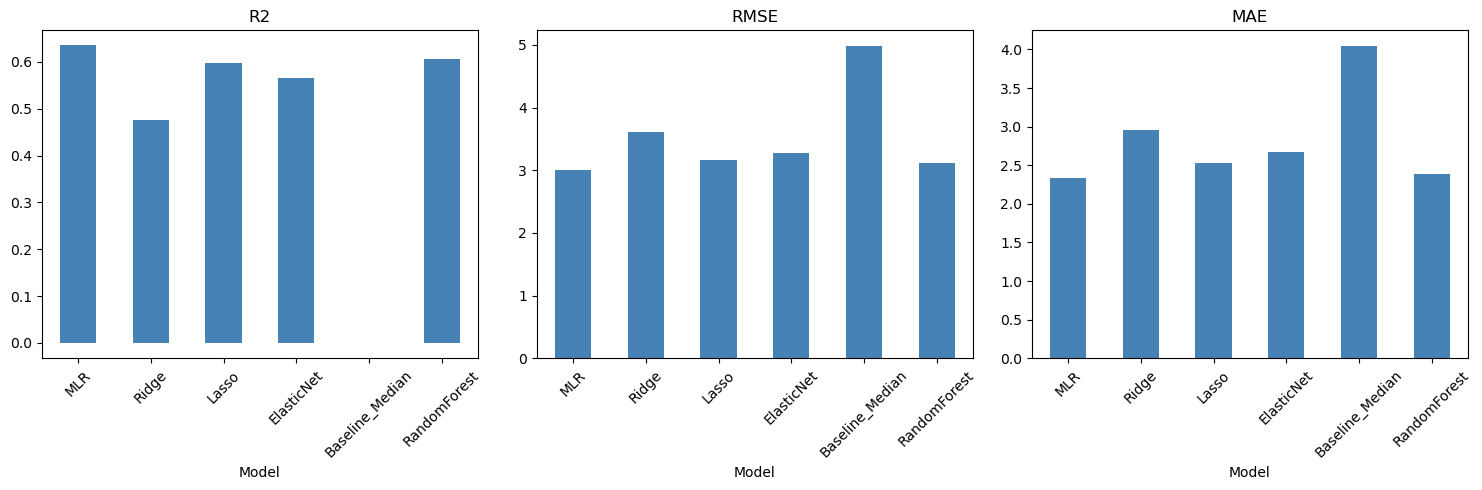

In [156]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    results_df[metric].plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlabel('Model')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/model_comparison_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

2. Confusion matrix heatmaps (all 5 models, one figure)

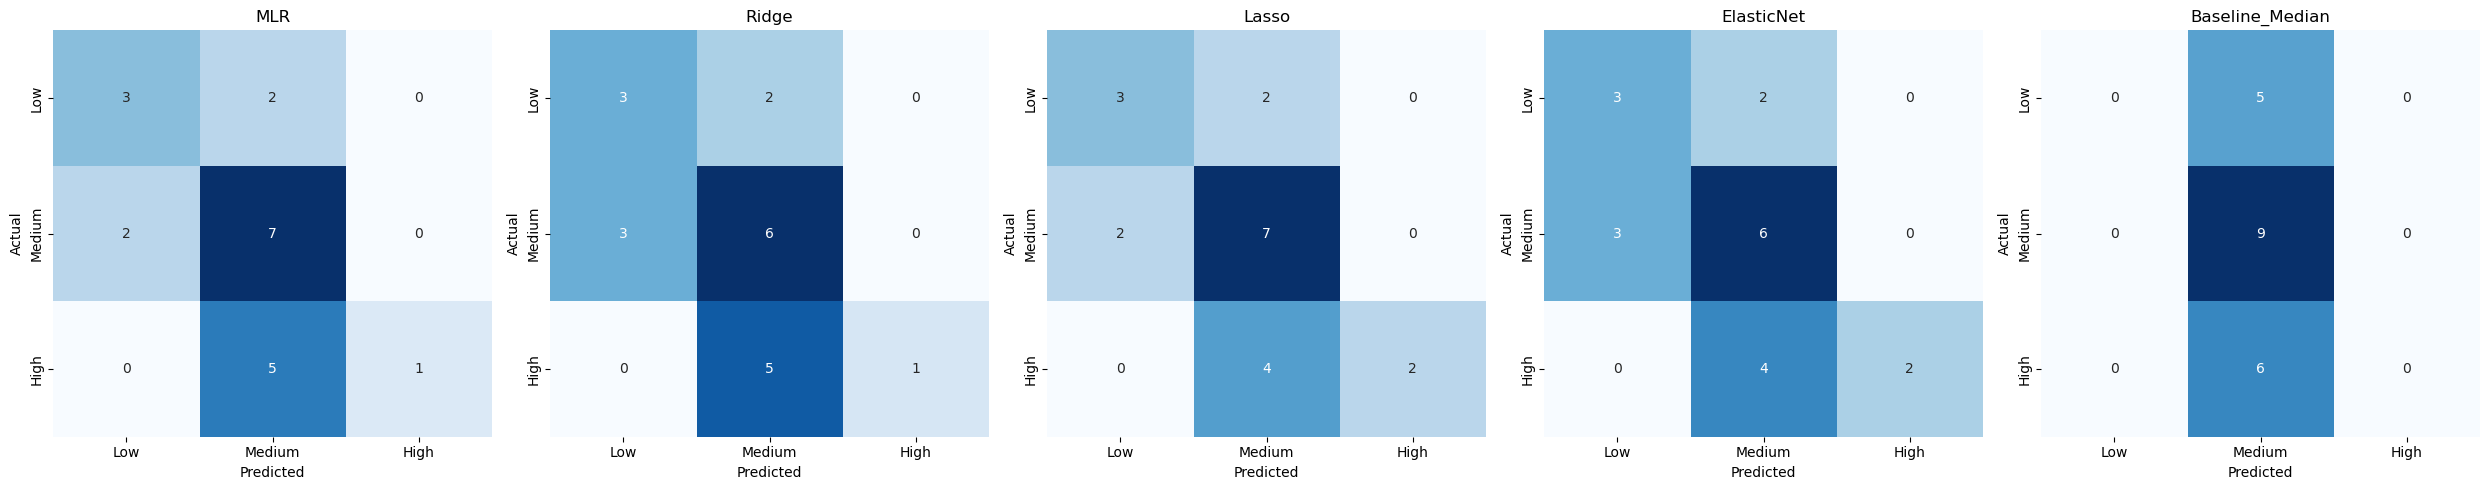

In [157]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for ax, (name, pipe) in zip(axes, pipelines.items()):
    preds_log = pipe.predict(X_test)

    # Convert predictions back to actual malaria case counts
    preds_raw = np.expm1(preds_log)

    pred_tiers = to_tier(preds_raw, q1, q3)
    cm = confusion_matrix(y_test_tiers, pred_tiers, labels=['Low', 'Medium', 'High'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'],
                ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('../figures/confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
plt.show()

In [158]:
print(f"Q1: {q1:,.0f}")
print(f"Q3: {q3:,.0f}")

Q1: 876
Q3: 1,205,326


# 8. Five Fold Cross Validation
We need to check if we just got lucky


In [159]:
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

cv_results = {}

for name, pipe in pipelines.items():
    scores = cross_val_score(
        pipe,
        X,
        y,
        cv=kf,
        scoring='r2'
    )
    
    cv_results[name] = {
        'Mean R²': scores.mean(),
        'Std R²': scores.std(),
        'Fold 1': scores[0],
        'Fold 2': scores[1],
        'Fold 3': scores[2],
        'Fold 4': scores[3],
        'Fold 5': scores[4]
    }

cv_results_df = pd.DataFrame(cv_results).T

cv_results_df

,Mean R²,Std R²,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5
MLR,0.510778,0.273624,0.718245,0.439065,0.762701,0.010710,0.623172
Ridge,0.528611,0.218001,0.706113,0.468700,0.735174,0.134888,0.598182
Lasso,0.496051,0.260832,0.729318,0.451023,0.723072,0.018267,0.558574
ElasticNet,0.536057,0.196496,0.711306,0.459695,0.757425,0.208262,0.543595
Baseline_Median,-0.080987,0.129322,-0.006985,-0.336718,-0.054451,-0.002906,-0.003878
RandomForest,0.595613,0.111942,0.696851,0.531521,0.760700,0.511741,0.477250


In [160]:
# 